# Exploring how to make cyclone relative composites using TempestExtremes NodeFileFilter and NodeFileCompose

In [ ]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings

#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

## custom packages:
from download_era5_composite import timestamps_from_etc_summary, build_date_groups, download, OUT_DIR

## First method (not using anymore)

In [ ]:
## full 1996-2025 summaries (swap these for the full-period files once the TE run finishes)
etc_summary = pd.read_csv('etc_summary_2.csv')
nodes_with_reports = pd.read_csv('nodes_with_reports_2.csv')

In [7]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind
0,1.0,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115,0,0,0,0
1,2.0,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59,0,0,0,0
2,3.0,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102,0,0,0,0
3,4.0,2020-01-03 11:00:00+00:00,2020-01-08 23:00:00+00:00,2020-01-08 10:00:00+00:00,990.7425,133,0,0,0,0
4,5.0,2020-01-04 00:00:00+00:00,2020-01-06 18:00:00+00:00,2020-01-06 15:00:00+00:00,951.6381,62,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...
58,69.0,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197,0,0,0,0
59,70.0,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137,465,24,266,175
60,72.0,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38,113,16,0,97
61,73.0,2020-03-30 11:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1006.8550,36,0,0,0,0


In [9]:
nodes_with_reports

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
0,1,2020-01-01 00:00:00+00:00,44.50,-67.00,991.6106,0,0,0,0
1,1,2020-01-01 01:00:00+00:00,44.75,-66.75,991.2206,0,0,0,0
2,1,2020-01-01 02:00:00+00:00,45.00,-66.50,991.4325,0,0,0,0
3,1,2020-01-01 03:00:00+00:00,45.25,-66.25,991.0762,0,0,0,0
4,1,2020-01-01 04:00:00+00:00,45.50,-66.00,990.5550,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7235,74,2020-03-31 19:00:00+00:00,44.50,-105.25,1004.1650,0,0,0,0
7236,74,2020-03-31 20:00:00+00:00,44.50,-104.50,1003.3780,0,0,0,0
7237,74,2020-03-31 21:00:00+00:00,44.50,-103.75,1002.9580,0,0,0,0
7238,74,2020-03-31 22:00:00+00:00,43.75,-102.75,1003.1310,0,0,0,0


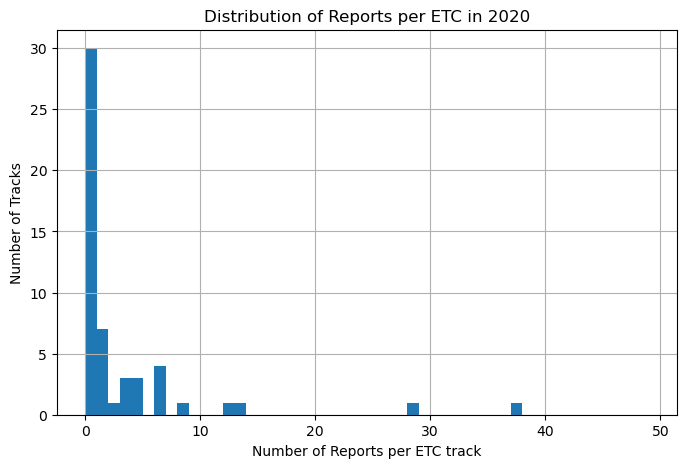

In [8]:
plt.figure(figsize=(8,5))
plt.hist(etc_summary['n_reports'], bins=np.arange(0,50,1))
plt.xlabel('Number of Reports per ETC track')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Reports per ETC in 2020')
plt.grid(True);

In [13]:
print(etc_summary['n_reports'].describe())

count     65.000000
mean      37.276923
std      115.506021
min        0.000000
25%        0.000000
50%        1.000000
75%        6.000000
max      686.000000
Name: n_reports, dtype: float64


In [25]:
len(etc_summary)

65

In [ ]:
print(len(etc_summary[etc_summary['n_reports'] >=10]))
print(len(etc_summary[etc_summary['n_reports'] == 0]))

14
32


Any cyclone that produces **at least one** storm report is an "outbreak cyclone" (OC); cyclones with **zero** reports are non-outbreak (NOC). No report-count threshold for now — outbreak clustering/detrending (Shafer & Doswell 2011, with KDE-identified outbreak clusters) comes later.

### Choosing reference time:

Later I could use KDE core onset times to use as reference times for compositing, but for now I'll just use min msl. Since several cyclones have multiple outbreak cores, it creates ambiguity in what reference time to use.

In [ ]:
tracks_oc = nodes_with_reports[nodes_with_reports['n_reports ']]

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
0,8245,2020-01-01 00:00:00+00:00,67.25,-27.50,972.9406,0,0,0,0
1,8245,2020-01-01 01:00:00+00:00,67.50,-26.75,972.2656,0,0,0,0
2,8245,2020-01-01 02:00:00+00:00,67.50,-26.00,971.7975,0,0,0,0
3,8245,2020-01-01 03:00:00+00:00,67.50,-26.00,971.3462,0,0,0,0
4,8245,2020-01-01 04:00:00+00:00,67.75,-25.25,971.3850,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7314,8320,2020-03-31 19:00:00+00:00,44.50,-105.25,1004.1650,0,0,0,0
7315,8320,2020-03-31 20:00:00+00:00,44.50,-104.50,1003.3780,0,0,0,0
7316,8320,2020-03-31 21:00:00+00:00,44.50,-103.75,1002.9580,0,0,0,0
7317,8320,2020-03-31 22:00:00+00:00,43.75,-102.75,1003.1310,0,0,0,0


In [33]:
nodes_with_reports['n_reports'].describe()

count    7319.000000
mean        0.331056
std         2.746133
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        82.000000
Name: n_reports, dtype: float64

## Creating two TempestExtremes nodefiles, each with one node per cyclone (the node at that cyclone's time_min_msl)

Full **DJFM 1996–2025** run. December is treated as in-season and attached to the **following** year's JFM (e.g. Dec 2019 → season 2020).

In [ ]:
MASTER_NODEFILE = "/data1/lepique/era5_test/track_sensitivities/tracks_hourly_2020_9.txt"     # <-- UPDATE: point to the full 1996-2025 StitchNodes nodefile

def diagnose(master_nodefile, etc_summary):
    print("=== etc_summary columns ===")
    print(list(etc_summary.columns))
    print("\n=== etc_summary dtypes (relevant) ===")
    print(etc_summary.dtypes)
    print("\n=== etc_summary head ===")
    print(etc_summary.head())

    print("\n=== first 6 lines of master nodefile ===")
    with open(master_nodefile) as f:
        for i, line in enumerate(f):
            print(repr(line.rstrip("\n")))
            if i >= 5:
                break

In [4]:
diagnose(MASTER_NODEFILE, etc_summary)

=== etc_summary columns ===
['track_id', 'track_start', 'track_end', 'time_min_msl', 'min_msl', 'n_steps', 'n_reports', 'n_tornado', 'n_hail', 'n_wind']

=== etc_summary dtypes (relevant) ===
track_id        float64
track_start      object
track_end        object
time_min_msl     object
min_msl         float64
n_steps           int64
n_reports         int64
n_tornado         int64
n_hail            int64
n_wind            int64
dtype: object

=== etc_summary head ===
   track_id                track_start                  track_end  \
0       1.0  2020-01-01 00:00:00+00:00  2020-01-05 22:00:00+00:00   
1       2.0  2020-01-01 11:00:00+00:00  2020-01-04 04:00:00+00:00   
2       3.0  2020-01-02 13:00:00+00:00  2020-01-06 23:00:00+00:00   
3       4.0  2020-01-03 11:00:00+00:00  2020-01-08 23:00:00+00:00   
4       5.0  2020-01-04 00:00:00+00:00  2020-01-06 18:00:00+00:00   

                time_min_msl   min_msl  n_steps  n_reports  n_tornado  n_hail  \
0  2020-01-05 03:00:00+00:00  95

In [ ]:
## CONFIG
REFERENCE = "min_msl" ## time to center the composite on (can use "max_reports")
COL_TRACKID = "track_id"
COL_NREPORTS = "n_reports"
COL_TIMEMAXREP = "time_max_reports"
COL_TIMEMSL = "time_min_msl"
REF_TIME_COL = COL_TIMEMSL if REFERENCE == "min_msl" else COL_TIMEMAXREP


## node data columns AFTER the two grid indices:
NODE_DATA_COLS = ["lon", "lat", "msl", "phis"]

## OC / NOC split: ANY cyclone with >=1 storm report is an "outbreak cyclone".
## No report-count threshold for now -- outbreak clustering/detrending
## (Shafer & Doswell 2011, with KDE-identified outbreak clusters) comes later.
## NOC = exactly 0 reports. Together these partition every in-season cyclone.

## DJFM season for the full 1996-2025 run. December is in-season and is attached
## to the FOLLOWING year's JFM (e.g. Dec 2019 -> season 2020), via season_year().
MONTHS = (12, 1, 2, 3)

def season_year(ts):
    """DJFM season label: December belongs to the following year's JFM season."""
    ts = pd.Timestamp(ts)
    return ts.year + 1 if ts.month == 12 else ts.year

OUT_OC = "outbreak_cyclones_min_msl.txt"
OUT_NOC = "nonoutbreak_cyclones_min_msl.txt"

## ERA5 domain [N, W, S, E] -- kept in sync with download_era5_composite.py,
## which holds the authoritative ERA5 download config (variables, levels, the
## 9 min-MSL +/- offset reference times). Used here only for the southern-
## boundary check in select_reference_nodes.
ERA5_AREA = [70, -140, -10, -50]

In [ ]:
## new helper to compute each cylone's max reports time
def add_max_report_time(etc_summary, node_reports,
                        id_col="track_id", time_col="time_hour",
                        rep_col="n_reports"):
    nr = node_reports.copy()
    nr[time_col] = pd.to_datetime(nr[time_col], utc=True)
    # most reporting node per track; ties -> earliest time
    top = (nr.sort_values([id_col, rep_col, time_col],
                          ascending=[True, False, True])
             .groupby(id_col, as_index=False)
             .head(1))
    # max-report time is only meaningful when the track actually has reports;
    # tracks with 0 reports get NaN (filled with min-MSL below)
    top = top[top[rep_col] > 0]
    time_max = top.set_index(id_col)[time_col]
    es = etc_summary.copy()
    es[COL_TIMEMAXREP] = es[COL_TRACKID].map(time_max)
    return es

etc_summary = add_max_report_time(etc_summary, nodes_with_reports)
#etc_summary[REF_TIME_COL] = etc_summary[COL_TIMEMAXREP].fillna(etc_summary[COL_TIMEMSL]) ## this fills time-max-reports column with the min-msl time for cyclones with no reports, but I don't think I want to actually do that

In [7]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,time_max_reports
0,1.0,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115,0,0,0,0,NaT
1,2.0,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59,0,0,0,0,NaT
2,3.0,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102,0,0,0,0,NaT
3,4.0,2020-01-03 11:00:00+00:00,2020-01-08 23:00:00+00:00,2020-01-08 10:00:00+00:00,990.7425,133,0,0,0,0,NaT
4,5.0,2020-01-04 00:00:00+00:00,2020-01-06 18:00:00+00:00,2020-01-06 15:00:00+00:00,951.6381,62,2,2,0,0,2020-01-04 15:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
58,69.0,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197,0,0,0,0,NaT
59,70.0,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137,465,24,266,175,2020-03-29 06:00:00+00:00
60,72.0,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38,113,16,0,97,2020-03-31 14:00:00+00:00
61,73.0,2020-03-30 11:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1006.8550,36,0,0,0,0,NaT


In [ ]:
## Parse nodefile 
def parse_nodefile(path, data_cols):
    """
    Parse TE StitchNodes nodefile. track_id is 1-indexed (first block = 1) to
    match etc_summary. Datetime build is vectorized so it scales to the full
    1996-2025 record.
    """

    rows = []
    with open(path) as f:
        lines = [ln.rstrip("\n") for ln in f]

    i = 0
    tid = 0
    n_data = len(data_cols)
    while i < len(lines):
        parts = lines[i].split()
        if not parts:
            i += 1
            continue
        if parts[0] == "start":
            tid +=1
            n_steps = int(parts[1])
            for k in range(1, n_steps + 1):
                np_ = lines[i+k].split()
                grid_i, grid_j = int(np_[0]), int(np_[1])
                data_vals = np_[2:2 + n_data]
                yyyy, mm, dd, off = np_[2 + n_data:2 + n_data + 4]
                row = {
                    "track_id": float(tid),
                    "grid_i": grid_i, "grid_j": grid_j,
                    "year": int(yyyy), "month": int(mm),
                    "day": int(dd), "offset": off,
                }
                for c, v in zip(data_cols, data_vals):
                    row[c] = float(v)
                rows.append(row)
            i += n_steps + 1
        else:
            i +=1
    
    df = pd.DataFrame(rows)
    ## "offset" is the hour-of-day field; build tz-aware UTC datetimes vectorized
    df["datetime"] = (
        pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]),
                       utc=True)
        + pd.to_timedelta(df["offset"].astype(float), unit="h")
    )

    return df


In [ ]:
## label OC/NOC, pick reference node
def select_reference_nodes(nodes_df, etc_summary, ref_time_col):
    es = etc_summary[[COL_TRACKID, COL_NREPORTS, ref_time_col]].copy()
    es[ref_time_col] = pd.to_datetime(es[ref_time_col], utc=True)
    es = es.dropna(subset=[ref_time_col])              ## need a reference time
    es = es[es[ref_time_col].dt.month.isin(MONTHS)]    ## DJFM only (December in-season)
    es["is_oc"] = es[COL_NREPORTS] > 0                 ## >=1 report -> outbreak; 0 -> NOC
    es["season_year"] = es[ref_time_col].apply(season_year)   ## Dec -> following JFM

    ## vectorized nearest-node pick (scales to the full 1996-2025 record)
    merged = nodes_df.merge(
        es[[COL_TRACKID, ref_time_col, COL_NREPORTS, "is_oc", "season_year"]],
        on=COL_TRACKID, how="inner",
    )
    merged["dt_diff"] = (merged["datetime"] - merged[ref_time_col]).abs()
    idx = merged.groupby(COL_TRACKID)["dt_diff"].idxmin()
    picks_df = merged.loc[idx].sort_values(COL_TRACKID).reset_index(drop=True)

    ## tracks requested (in-season, with a reference time) but absent from the nodefile
    missing = sorted(set(es[COL_TRACKID]) - set(picks_df[COL_TRACKID]))
    if missing:
        head = ", ".join(f"{m:.0f}" for m in missing[:10])
        print(f"WARNING: {len(missing)} track(s) not in nodefile: {head}"
              f"{' ...' if len(missing) > 10 else ''}")

    ## flag any pick whose nearest node is > 1 h from the reference time
    far = picks_df[picks_df["dt_diff"] > pd.Timedelta(hours=1)]
    for _, n in far.iterrows():
        print(f"NOTE: track {n[COL_TRACKID]:.0f} nearest node "
              f"{n['dt_diff']} from {ref_time_col}")

    print(f"\n  DJFM seasons : {picks_df['season_year'].min():.0f}-"
          f"{picks_df['season_year'].max():.0f} "
          f"({picks_df['season_year'].nunique()} seasons)")
    print(f"  OC  (>=1 report): {int(picks_df['is_oc'].sum())}")
    print(f"  NOC (0 reports) : {int((~picks_df['is_oc']).sum())}")

    ## per-season OC / NOC / total (record-keeping for the full period)
    by_season = picks_df.groupby("season_year")["is_oc"].agg(OC="sum", total="size")
    by_season["NOC"] = by_season["total"] - by_season["OC"]
    print("\n  per-season (OC / NOC / total):")
    for yr, r in by_season.iterrows():
        print(f"    {yr:.0f}: {int(r['OC']):4d} / {int(r['NOC']):4d} / {int(r['total']):4d}")

    ## warn if any node is within ~20 deg of the ERA5 southern boundary
    south_edge = ERA5_AREA[2]
    too_south = picks_df[picks_df["lat"] - 20 < south_edge]
    if len(too_south):
        print(f"\n  DOMAIN WARNING: {len(too_south)} node(s) within 20 deg of "
              f"southern boundary ({south_edge} N):")
        for _, n in too_south.iterrows():
            print(f"    track {n['track_id']:.0f}  lat={n['lat']:.2f}  "
                  f"-> radius reaches {n['lat']-20:.1f} N")
    return picks_df

In [10]:
## write single-snapshot nodefiles (what will be the input to TE)
def write_snapshot_nodefile(subset, out_path, data_cols):
    with open(out_path, "w") as f:
        for _, r in subset.iterrows():
            yyyy, mm, dd, off = int(r["year"]), int(r["month"]), int(r["day"]), r["offset"]
            data_str = "\t".join(f"{r[c]:.6f}" for c in data_cols)
            f.write(f"start\t1\t{yyyy}\t{mm}\t{dd}\t{off}\n")
            f.write(f"\t{int(r['grid_i'])}\t{int(r['grid_j'])}\t{data_str}"
                    f"\t{yyyy}\t{mm}\t{dd}\t{off}\n")
    print(f" wrote {len(subset)} -> {out_path}")

In [ ]:
## driver: build the two single-node-per-cyclone nodefiles for NodeFileCompose
## over the full DJFM 1996-2025 record. OC = cyclones with >=1 report, NOC = 0
## reports -> outbreak_cyclones_min_msl.txt, nonoutbreak_cyclones_min_msl.txt
def run_all(master_nodefile, etc_summary, ref_time_col=REF_TIME_COL):
    nodes_df = parse_nodefile(master_nodefile, NODE_DATA_COLS)
    print(f"Parsed {nodes_df['track_id'].nunique()} tracks, {len(nodes_df)} nodes.")
    picks_df = select_reference_nodes(nodes_df, etc_summary, ref_time_col)
    write_snapshot_nodefile(picks_df[picks_df["is_oc"]],  OUT_OC,  NODE_DATA_COLS)
    write_snapshot_nodefile(picks_df[~picks_df["is_oc"]], OUT_NOC, NODE_DATA_COLS)
    return nodes_df, picks_df

In [12]:
nodes_df, picks_df = run_all(MASTER_NODEFILE, etc_summary)

Parsed 230 tracks, 28528 nodes.

  OC  (n_reports >= 10): 14
  NOC (n_reports <  10): 49

  DOMAIN WARNING: 6 node(s) within 20 deg of southern boundary (15 N):
    track 11  lat=27.25  -> radius reaches 7.2 N
    track 19  lat=25.50  -> radius reaches 5.5 N
    track 21  lat=28.50  -> radius reaches 8.5 N
    track 26  lat=30.50  -> radius reaches 10.5 N
    track 27  lat=28.50  -> radius reaches 8.5 N
    track 72  lat=33.25  -> radius reaches 13.2 N
 wrote 14 -> outbreak_cyclones_min_msl.txt
 wrote 49 -> nonoutbreak_cyclones_min_msl.txt


Use python script (@download_era5_composite.py) to download the corresponding ERA5 data to input into NodeFileCompose to generate composites

## Downloading ERA5 data for NodeFileCompose

use python script 

## Plotting Composite Output

### MSL:

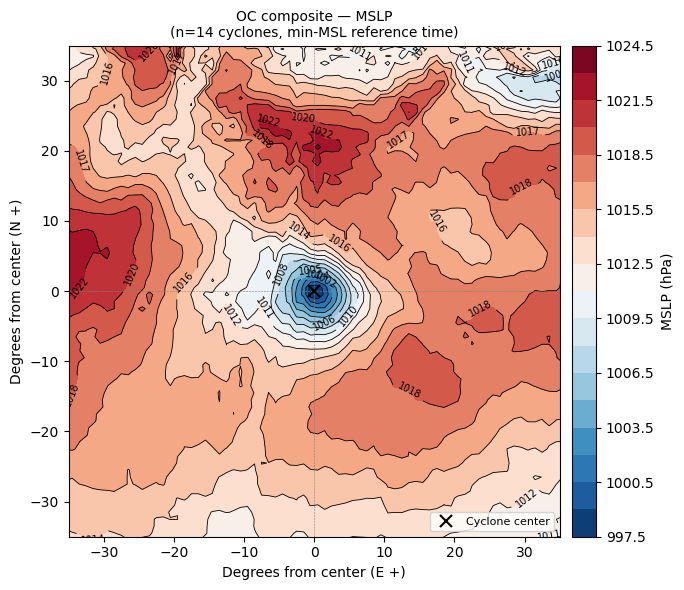

In [9]:
ds = xr.open_dataset('test_noc_msl.nc')

msl = ds['msl'] / 100 #Pa to hPa

fig, ax = plt.subplots(figsize=(7,6))

# filled contours for background shading
cf = ax.contourf(
    ds["x"], ds["y"], msl,
    levels=20,
    cmap="RdBu_r",
)

# line contours with labels
cs = ax.contour(
    ds["x"], ds["y"], msl,
    levels=20,
    colors="k",
    linewidths=0.6,
)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

# mark cyclone center
ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5, label="Cyclone center")

cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("MSLP (hPa)", fontsize=10)

ax.set_xlabel("Degrees from center (E +)", fontsize=10)
ax.set_ylabel("Degrees from center (N +)", fontsize=10)
ax.set_xlim(-35,35)
ax.set_ylim(-35,35)
ax.set_title("OC composite — MSLP\n(n=14 cyclones, min-MSL reference time)", fontsize=10)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

In [12]:
ds_oc = xr.open_dataset('test_oc_msl.nc')
ds_noc = xr.open_dataset('test_noc_msl.nc')

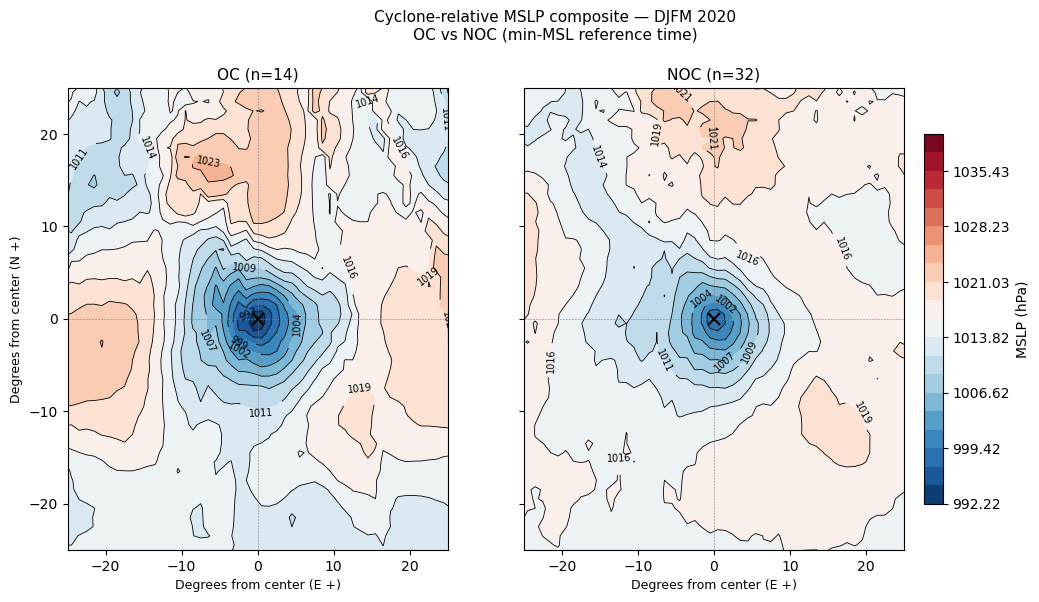

In [22]:
ds_oc  = xr.open_dataset("test_oc_msl.nc")
ds_noc = xr.open_dataset("test_noc_msl.nc")

msl_oc  = ds_oc["msl"]  / 100   # Pa -> hPa
msl_noc = ds_noc["msl"] / 100

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(msl_oc.values), np.nanmin(msl_noc.values))
vmax = max(np.nanmax(msl_oc.values), np.nanmax(msl_noc.values))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [msl_oc, msl_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="RdBu_r",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative MSLP composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

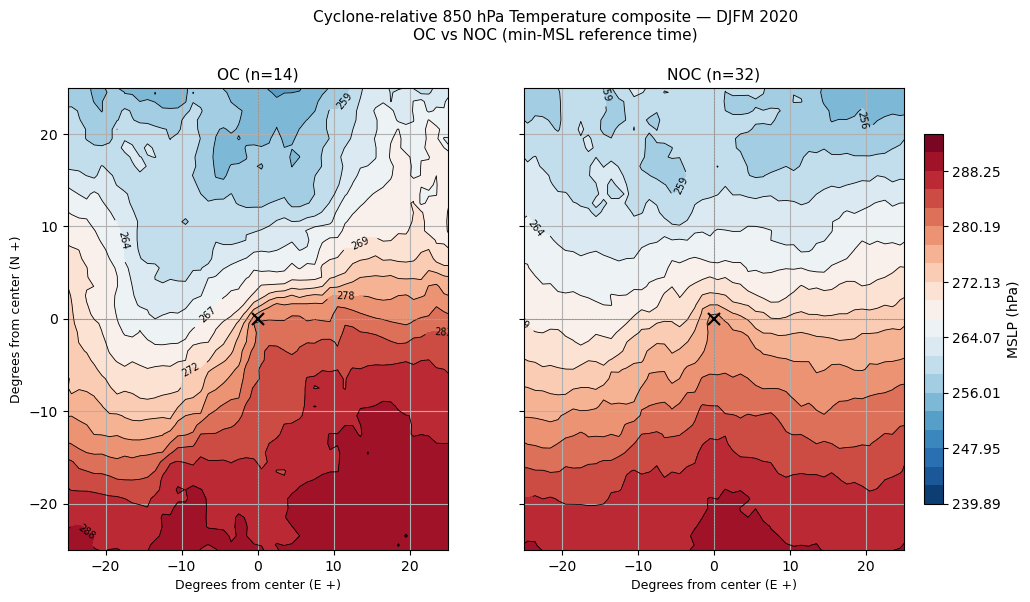

In [20]:
ds_oc  = xr.open_dataset("test_oc_t.nc")
ds_noc = xr.open_dataset("test_noc_t.nc")

t_oc  = ds_oc["t(0)"]  
t_noc = ds_noc["t(0)"] 

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(t_oc.values), np.nanmin(t_noc.values))
vmax = max(np.nanmax(t_oc.values), np.nanmax(t_noc.values))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [t_oc, t_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="RdBu_r",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative 850 hPa Temperature composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

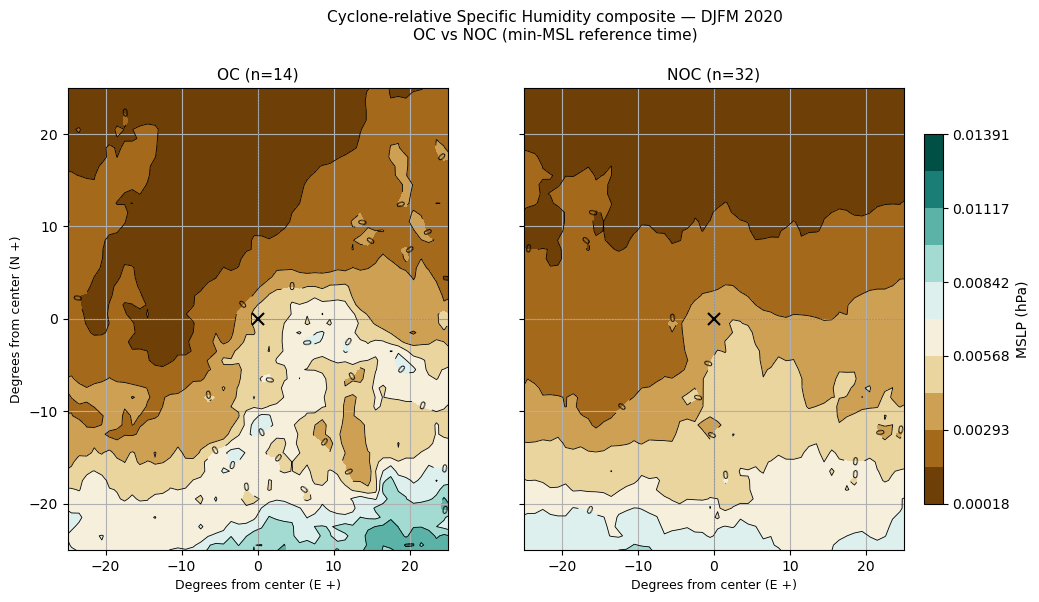

In [ ]:
ds_oc  = xr.open_dataset("test_oc_q.nc")
ds_noc = xr.open_dataset("test_noc_q.nc")

q_oc  = ds_oc["q(0)"]      
q_noc = ds_noc["q(0)"]  

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(q_oc.values), np.nanmin(q_noc.values))
vmax = max(np.nanmax(q_oc.values), np.nanmax(q_noc.values))
levels = np.linspace(vmin, vmax, 11)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, msl, title in zip(
    axes,
    [q_oc, q_noc],
    [f"OC (n=14)", f"NOC (n=32)"],
):
    cf = ax.contourf(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, cmap="BrBG",
    )
    cs = ax.contour(
        ds_oc["x"], ds_oc["y"], msl,
        levels=levels, colors="k", linewidths=0.6,
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
    ax.set_xlim(-25, 25)
    ax.set_ylim(-25, 25)
    ax.grid(True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)
    

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# Single shared colorbar on the right
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("MSLP (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative Specific Humidity composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.01)

#plt.tight_layout()
#plt.savefig("oc_noc_msl_composite.png", dpi=180, bbox_inches="tight")
plt.show()

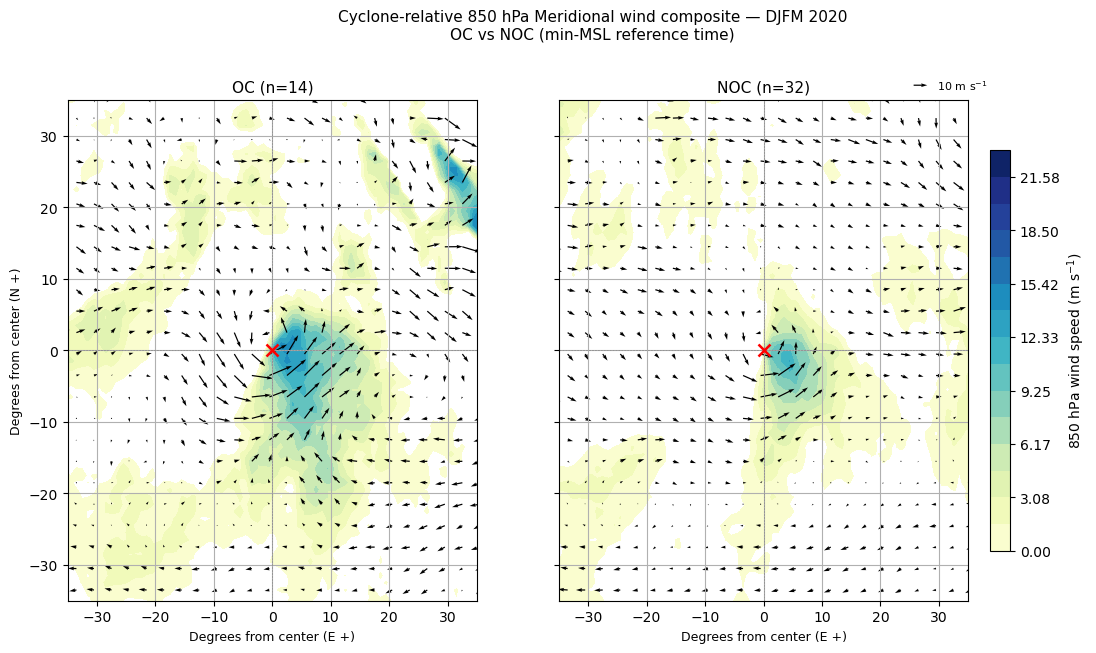

In [3]:

# --- load both populations ---
u_oc  = xr.open_dataset("test_oc_u.nc")["u(0)"]
v_oc  = xr.open_dataset("test_oc_v.nc")["v(0)"]
u_noc = xr.open_dataset("test_noc_u.nc")["u(0)"]
v_noc = xr.open_dataset("test_noc_v.nc")["v(0)"]

spd_oc  = np.sqrt(u_oc**2  + v_oc**2)
spd_noc = np.sqrt(u_noc**2 + v_noc**2)

x = u_oc["x"]
y = u_oc["y"]

# shared speed scale across both panels for comparability
vmax = max(np.nanmax(spd_oc.values), np.nanmax(spd_noc.values))
levels = np.linspace(0, vmax, 16)

skip = 3
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)

panels = [
    (axes[0], u_oc,  v_oc,  spd_oc,  "OC (n=14)"),
    (axes[1], u_noc, v_noc, spd_noc, "NOC (n=32)"),
]

for ax, u, v, spd, title in panels:
    cf = ax.contourf(x, y, v, levels=levels, cmap="YlGnBu")

    q = ax.quiver(
        x[::skip], y[::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )

    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.plot(0, 0, "rx", markersize=9, markeredgewidth=1.8)
    ax.grid(True)
    ax.set_xlim(-35, 35)
    ax.set_ylim(-35, 35)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degrees from center (E +)", fontsize=9)

# reference arrow on the second panel
ax.quiverkey(q, 0.9, 1.03, 10, "10 m s$^{-1}$",
             labelpos="E", fontproperties={"size": 8})

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

# single shared colorbar
cbar = fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("850 hPa wind speed (m s$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative 850 hPa Meridional wind composite — DJFM 2020\nOC vs NOC (min-MSL reference time)",
             fontsize=11, y=1.02)

#plt.savefig("oc_noc_wind850_composite.png", dpi=180, bbox_inches="tight")
plt.show()